<a href="https://colab.research.google.com/github/sarangis/python_learning/blob/main/MP2_NB_AI_Based_Incident_Management_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Mini-Project 2: AI-Based Incident Management System


## Learning Objectives

At the end of the mini-project, you will be able to :

* Understand how AI can automate and improve incident management workflows
* Convert unstructured incident data into structured insights through classification and extraction
* Design intelligent routing to decide between AI resolution and human intervention
* Apply LLMs to generate resolutions and draft user/customer responses
* Build an end-to-end AI-driven incident handling pipeline with feedback loops
* Analyze incident data and visualize trends for monitoring and decision-making

## Problem Statement

Organizations across industries handle a large volume of incidents originating from customers, internal users, and operational systems. These incidents may include service requests, technical issues, compliance queries, or process-related concerns.

Currently, incident management processes are often **manual, fragmented, and reactive**, leading to several challenges:

* **High response and resolution times**
* **Inconsistent handling of similar incidents**
* **Over-reliance on human agents for repetitive or low-complexity issues**
* **Lack of intelligent routing between automated systems and human support**
* **Limited visibility into incident patterns, root causes, and performance metrics**

A significant portion of incidents typically falls into two categories:

* **Policy or process-related issues**, where users lack awareness or clarity
* **Operational challenges**, involving system failures, exceptions, or complex scenarios

However, most existing systems lack the capability to:

* Automatically **understand and classify incidents from unstructured inputs**
* Determine whether an incident can be **resolved using AI or requires human intervention**
* Provide **consistent, context-aware resolutions in real time**
* Continuously improve through **feedback and learning loops**

*The goal is to design and develop an AI-based Incident Management System that can:*

* Automatically analyze and categorize airline incidents
* Identify the issue origin (policy vs operational)
* Decide whether the issue can be handled by AI or escalated to a human
* Generate accurate resolutions and customer responses
* Capture and analyze customer feedback
* Provide a dashboard for monitoring incident trends and performance



**AI-Based Incident Management System**

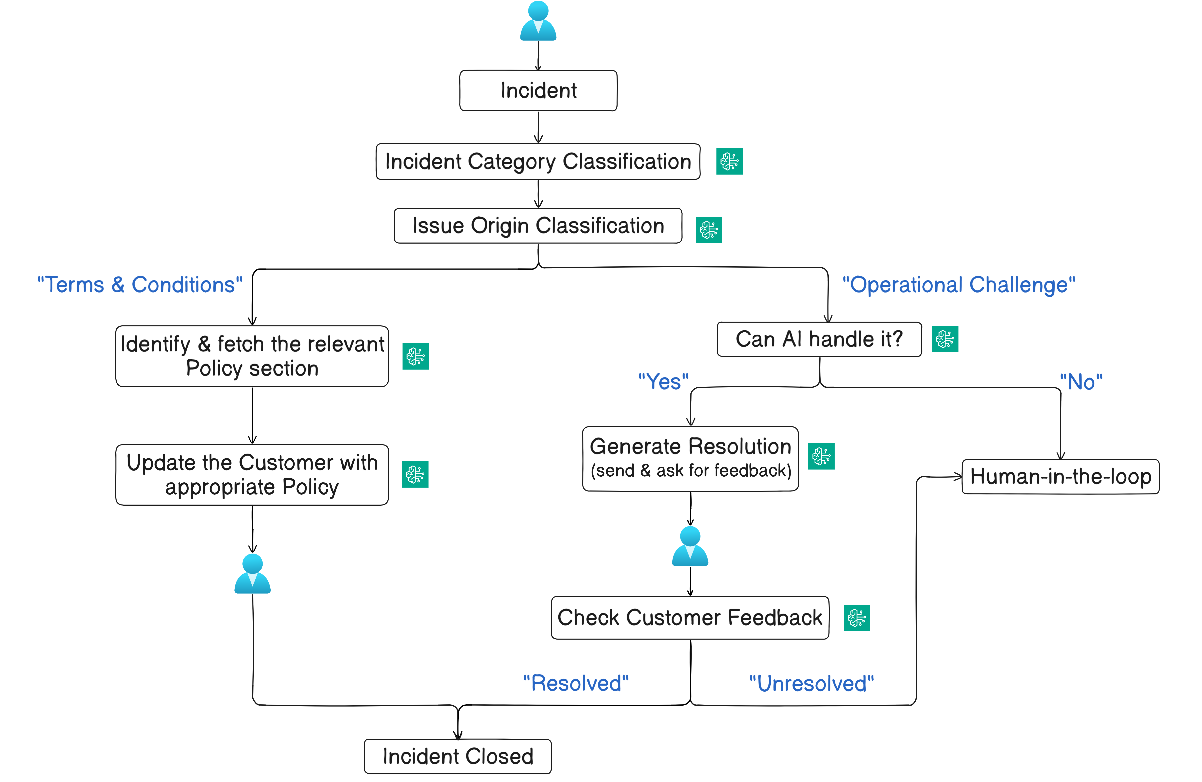

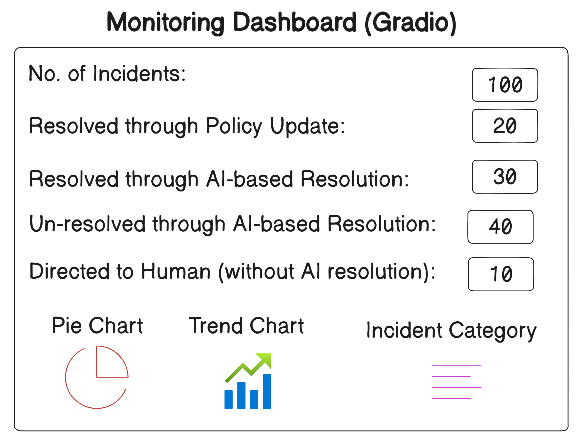

## Dataset

A few **sample incident descriptions** are provided for testing the pipeline:

- *Baggage did not arrive at destination and staff cannot trace it.*

- *Charged extra baggage fees even though within allowed weight.*

- *Suitcase was damaged during transit and wheels are completely broken.*

- *Received another passenger’s bag instead of mine at baggage claim area.*

- *Boarding pass QR code is not scanning at the boarding gate.*

- *Spelling mismatch between the ticket and boarding pass name.*

- *Unable to download boarding pass from mobile app after successful check-in.*

- *Online check-in is failing repeatedly and I cannot select my seat.*

- *Airport kiosk is not working and I might miss my flight check-in.*

- *Missed the check-in deadline and need urgent assistance for boarding.*

- *Forgot my ID at home and need help boarding the flight urgently.*

- *ID is expired and airline staff are not allowing check-in process.*

- *Name on the ID does not exactly match the booking details provided.*


## Grading = 10 Points

- **Part-A [6 Points]**

    **Build the Incident Management Pipeline**

    Design and implement all the required LLM chains to build a complete AI-based Incident Management Pipeline.

    This includes steps such as issue origin classification, incident category classification, policy mapping, AI vs human routing, resolution generation, and feedback evaluation.

    The goal is to create an end-to-end intelligent workflow that can process incidents from input to closure using structured LLM-driven decision-making.

---

- **Part-B [4 Points]**

    **Dashboard Development & Testing**
    
    Develop an interactive dashboard interface to visualize incident data and system performance.

    This includes building components such as summary metrics, trend charts, category distribution, and resolution insights.

    Also, test the complete pipeline using sample incidents to validate accuracy, performance, and usability of the system.

---


# **Part-A** Build the Incident Management Pipeline

### Install Required Libraries

In [ ]:
%%capture
!pip -q install groq==0.37.1
!pip -q install langchain-groq==1.1.2
!pip -q install langchain==1.2.12
!pip -q install langchain-core==1.2.19
!pip -q install langchain_community==0.4.1

### Import Neccesary Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from datetime import datetime

### Read the Groq API Key

Using the Groq API Key, you will have access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits).

This cell retrieves the Groq API key securely stored in Google Colab's Secrets (see 'key' icon on the leftmost panel of this notebook) and sets it as an environment variable `GROQ_API_KEY`. This is a recommended practice to avoid exposing your API key directly in the code.


* Go to https://console.groq.com/, and setup a Free account.

* Create a new API by visiting: https://console.groq.com/keys

* Save the key in Google Colab's Secrets
    ```
    Secret Name: GROQ_API_KEY
    Secret Value: Paste your Groq api key
    ```

* Read the key and save as an environment variable `GROQ_API_KEY`

In [ ]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

**Initialize a Chat Model**

For example: `openai/gpt-oss-20b`

### **Incident Category Classification**

Implement an **LLM chain** ( `incident_category_clf_chain` ) that classifies incidents into **predefined categories based on the incident description**.

The system should analyze the input text and assign it to the most relevant category such as **Baggage, Boarding Pass, Check-in, ID Proof, or Other**, ensuring consistency in downstream processing.

This classification enables **structured analysis, category-wise insights, and efficient routing within the incident management workflow**.


### **Issue Origin Classification**

Create an **LLM chain** ( `issue_origin_clf_chain` ) to identify whether an incident arises from **policy/process awareness gaps** or **operational challenges** based on the incident description.

Classify the issue into ONE of the following:
1. "Terms & Conditions / Process Awareness"
   - If the issue is due to lack of awareness, misunderstanding of policies, or standard rules

2. "Operational Challenge"
   - If the issue is caused by system failures, process breakdowns, logistics issues, or unexpected real-world problems

Use this classification to enable appropriate routing—either **AI-driven policy explanation** or **escalation for operational handling**.

### **Policy-Based Resolution (Terms & Conditions Handling)**

Implement an **LLM chain** ( `policy_resolution_chain` ) that **interprets policy-related incidents and generates clear, contextual policy explanations**.

The system should take the classified incident, map it to relevant policies or rules, and produce a **concise customer-facing response** without requiring human intervention.

This component should ensure **consistent, accurate, and automated handling of policy-based queries**, improving efficiency and response time.

**NOTE:** A sub-llm-chain might be required to indentify & fetch the relevant policy text.

In [ ]:
# Incidents

airline_policies = {
    "Baggage Policy": "..",
    "Boarding Policy": "...",

}


In [ ]:
# Airline Policies

airline_policy = {
    "Baggage Policy": """
    Delayed Baggage:
    Passengers must report delayed baggage immediately at the arrival airport. The airline will initiate a tracing process and provide updates.

    Lost Baggage:
    If baggage is not located within the defined tracing period, it will be declared lost. Passengers may file a compensation claim as per applicable regulations.

    Damaged Baggage:
    Damage must be reported before leaving the airport or within the allowed claim window. The airline will assess and provide repair, replacement, or compensation.

    Overweight / Extra Baggage:
    Additional charges apply for baggage exceeding the permitted allowance. Fees depend on route, fare type, and airline guidelines.

    Missing Items:
    Claims for missing items are subject to verification and may not be covered if items are restricted or undeclared.
    """,


    "Boarding Pass Policy": """
    Invalid Boarding Pass:
    Passengers must present a valid boarding pass. If scanning fails, a new pass may be issued after verification.

    Name Mismatch:
    The passenger name must match the travel document. Minor corrections may be allowed; major discrepancies may require rebooking or verification.

    Seat Allocation:
    Seat assignments are subject to availability and operational constraints. Airlines may change seats if required.

    Duplicate / Missing Boarding Pass:
    Boarding passes can be regenerated via official channels or at the airport desk.
    """,


    "Check-in Policy": """
    Online Check-in:
    Online check-in is available within a defined time window before departure. Eligibility depends on route and documentation requirements.

    Kiosk / Airport Check-in:
    If self-service kiosks fail, passengers should proceed to the airline counter for assistance.

    Check-in Deadline:
    Passengers must complete check-in before the deadline. Late arrivals may be denied boarding unless exceptions are allowed.

    Seat Selection:
    Seat selection depends on fare type and availability.
    """,


    "Identity & Verification Policy": """
    Valid Identification:
    Passengers must carry valid government-issued identification or travel documents.

    Name Matching:
    The name on the ticket must match the ID. Discrepancies may lead to denial of boarding.

    Expired Documents:
    Expired or invalid identification will not be accepted.

    Missing Identification:
    Passengers without valid ID may not be allowed to proceed unless alternative verification is approved.
    """
}

### **AI Handling Decision (Operational Incident Routing)**

Implement an **LLM-based decision system** ( `can_ai_handle_chain` ) to determine whether an operational incident **can be handled by AI or requires human intervention**.

The system should evaluate factors such as **issue frequency, impact/size, and customer relationship** to make an informed routing decision.

This component ensures **efficient automation of repetitive issues while safely escalating complex or sensitive cases to human agents**.


### **AI-Based Resolution Generation**

Implement an **LLM chain** ( `ai_resolution_chain` ) that **generates clear, actionable resolutions for incidents that can be handled by AI**.

The system should take the incident details and produce a **step-by-step resolution or guidance**, ensuring it is practical, concise, and directly useful to the user.

This component enables **automated resolution of common issues**, improving response time and reducing reliance on human support.


### **Customer Feedback Evaluation & Closure Decision**

Implement an **LLM chain** ( `feedback_eval_chain` ) that **analyzes customer feedback to determine whether the issue has been successfully resolved or remains unresolved**.

The system should interpret the feedback sentiment and intent to classify the outcome as **Resolved or Unresolved**.

This component enables **automated validation of resolution effectiveness** and supports decision-making for either closing the incident or routing it for further action.


## **Complete Pipeline (AI-Based Incident Management System)**

Write a Python function named to simulate the complete working of the **AI-based Incident Management System**.

Your function should perform the following steps in sequence:

**1. Accept the Incident Input**

* Display a welcome message for the user.
* Take the incident description as input using `input()`.
* Increment the total incident count in the `data` dictionary.

**2. Classify the Incident Category**

* Use the `incident_category_clf_chain` to classify the incident into one of the predefined categories.
* Based on the predicted category, update the corresponding count in the `incident_category_data` dictionary.

**3. Identify the Issue Origin**

* Use the `issue_origin_clf_chain` to determine whether the issue is related to:

  * **Terms & Conditions**
  * **Operational Challenge**

**4. Handle Terms & Conditions Cases**

* If the issue origin is **Terms & Conditions**, invoke the `policy_resolution_chain`.
* Display the generated response.
* Increment the **Resolved through Policy Update** count.

**5. Handle Operational Challenges**

* If the issue origin is **Operational Challenge**, use `can_ai_handle_chain` to check whether AI can resolve it.
* If the result is **Yes**:

  * Invoke the `ai_resolution_chain`
  * Display the generated response
  * Ask the user for feedback on whether the resolution helped
  * Use `feedback_eval_chain` to classify the feedback as **Resolved** or **Unresolved**
  * Update the corresponding counts in the `data` dictionary
* If the result is **No**:

  * Display the message stating "This incident is forwarded to the Support team
  * Increment the **Directed to Human (without AI Resolution)** count

**6. Add a Default Fallback**

* If the issue origin is neither of the expected values, route the request to human support by default.

---

**Additional Requirements**

* Use the already defined LLM chains directly in your code.
* Make sure dictionary keys are updated correctly.
* Print user-friendly responses at each stage.
* Ensure the pipeline follows the workflow exactly from **incident intake → classification → routing → resolution → feedback → closure/escalation**.

---

In [ ]:
# Initially keeping all metrics to 0.
# Update the values based on the incident routing through the pipeline.

data = {
    "Number of Incidents": 0,
    "Resolved through Policy Update": 0,
    "Resolved through AI-based Resolution": 0,
    "Unresolved through AI-based Resolution": 0,
    "Directed to Human (without AI Resolution)": 0
    }
data

In [ ]:
incident_category_data = {
    "Baggage related": 0,
    "Boarding pass related": 0,
    "Check-in related": 0,
    "ID Proof related": 0,
    "Other": 0
}
incident_category_data

# **Part-B** Dashboard Development & Testing

## **Monitoring Dashboard**

Create an interactive **Gradio Dashboard** to monitor the performance of the **AI-based Incident Management System** and visualize incident-related metrics.

Your dashboard should be built using the existing dictionaries such as `data` and `incident_category_data`, and should display both **summary information** and **charts**.

**1. Display Incident Summary Metrics**

* Convert the `data` dictionary into a tabular format using a Pandas DataFrame.
* Show the metrics vertically in the dashboard, for example:

  * Number of Incidents
  * Resolved through Policy Update
  * Resolved through AI-based Resolution
  * Unresolved through AI-based Resolution
  * Directed to Human (without AI Resolution)

**2. Add a Resolution Distribution Chart**

* Create a **Pie Chart** to visualize how incidents are distributed across:

  * Policy-based resolution
  * AI-based resolution
  * Unresolved after AI resolution
  * Human-directed cases
* Filter out categories with zero values so the chart remains clean and readable.

**3. Add an Incident Trend Chart**

* Build a **Line Plot** to show how the main metrics change over time.
* Store snapshots of the `data` dictionary at regular intervals.
* Update the trend chart only when there is a change in the `data` dictionary, so duplicate points are not added unnecessarily.

**4. Add an Incident Category Chart**

* Use the `incident_category_data` dictionary to create a **Bar Plot** showing the number of incidents in each category.
* Example categories may include:

  * Baggage related
  * Boarding pass related
  * Check-in related
  * ID Proof related

**5. Organize the Dashboard in Gradio**

* Place the table and charts in a structured layout using `gr.Row()` and `gr.Column()`
* Include suitable titles for each section
* Center the main dashboard title using HTML styling inside `gr.Markdown()`

**6. Enable Refresh / Auto-update**

* Add either:

  * a **Refresh button**, or
  * a **Gradio Timer**
* so the dashboard updates periodically with the latest values

**Additional Requirements**

* Use **Pandas** for tabular display
* Use **Matplotlib** for Pie, Line, and Bar charts
* Ensure charts handle cases where values may be zero
* Keep the interface clean, readable, and logically organized

---


**Example Dashboard:** (Your implementation may vary)

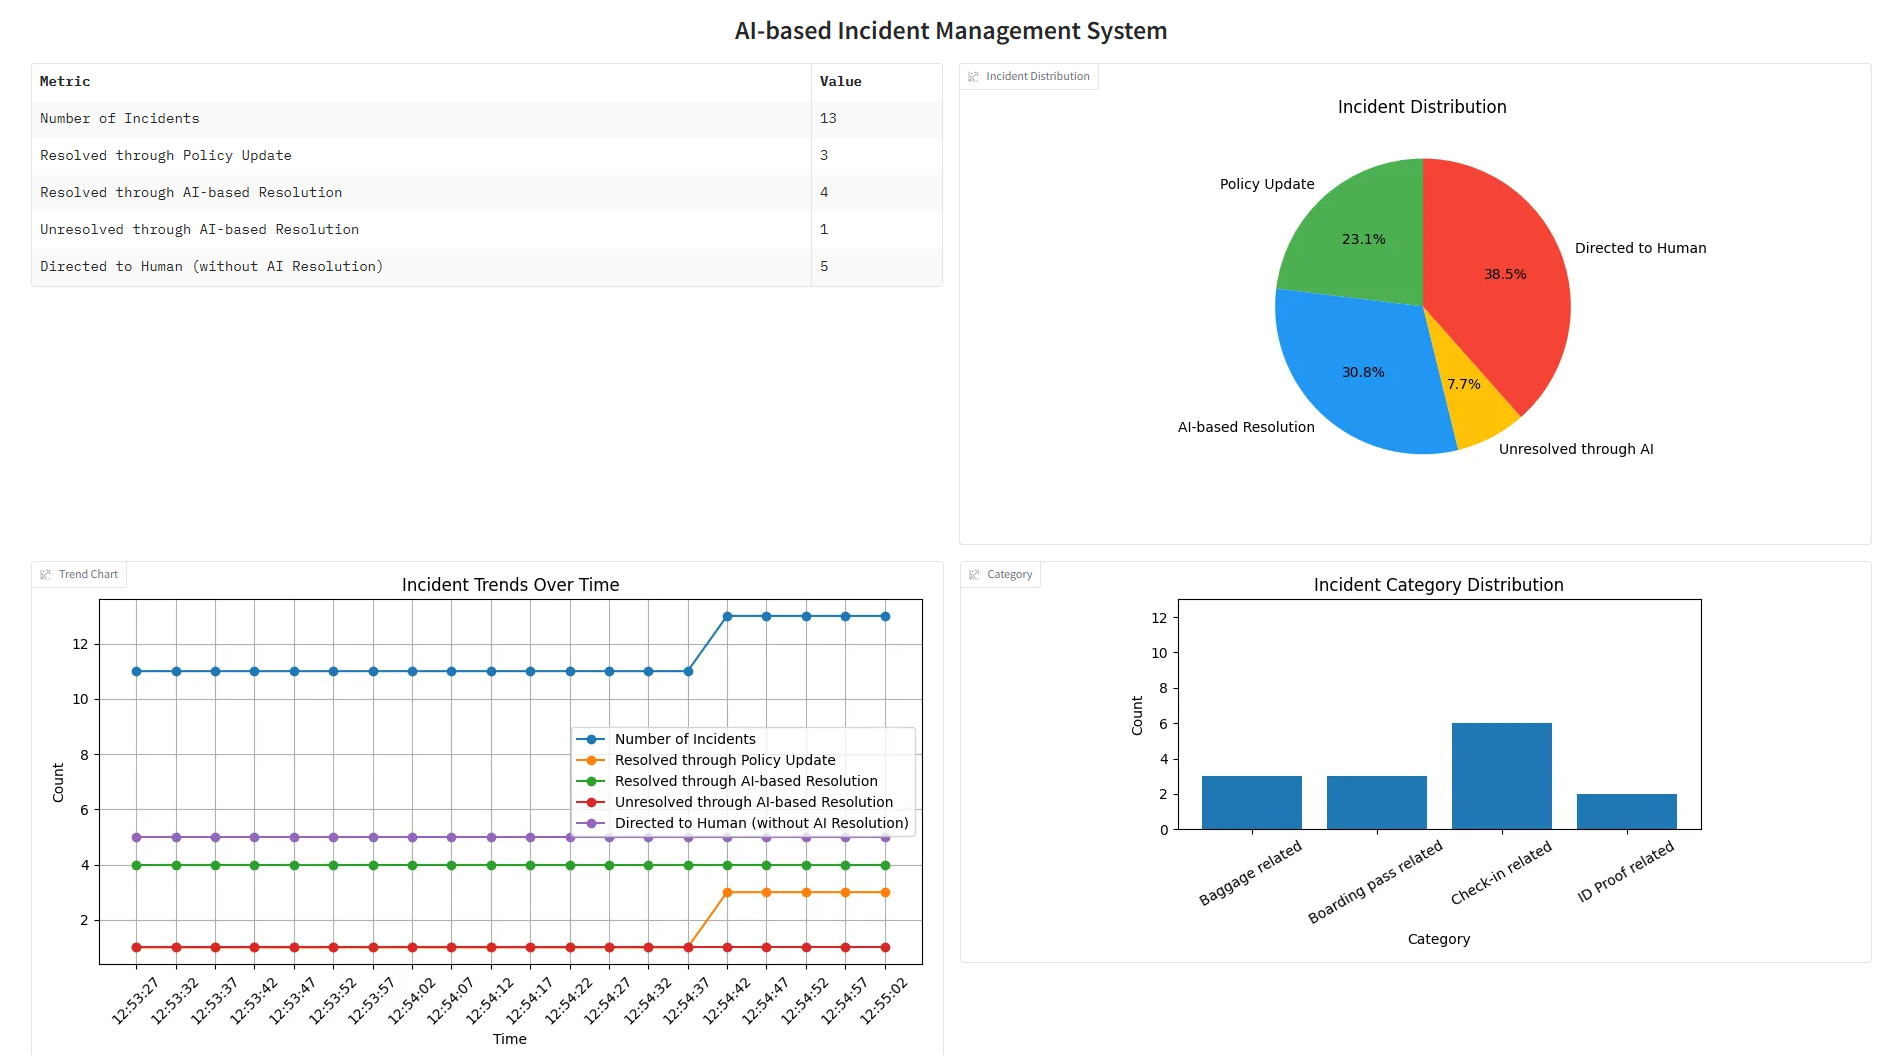

---

In [ ]:
import gradio as gr

### **Test the Dashboard**

- First, start the Dashboard Gradio Interface

- Then, run the Incident Management Pipeline and provide sample incidents

- Check the updates being reflected in the Dashboard

---

<center>
$END$
</center>

---